# 02c — CoT Feature Selection Analysis

**Purpose:** Analyze how consistently the LLM selects features and predicts ranges
across different prompts.

**Data source:** We reuse two existing JSON files that were originally produced for
different purposes:
- `cot_llm_a_results.json` — the 8 `TEST_PROMPTS` results from Method 2A evaluation
- `cot_training_data.json` — the same 8 results **plus** 51 LLM-generated extra prompts,
  originally created as synthetic training data for the small model (Method 3 / notebook 02b_method4).
  The small model was not ultimately trained with this data, but the LLM's feature selections
  and range predictions are still valuable for understanding CoT behavior.

Since CLAP and SBERT produce deterministic scores (same embeddings = same cosine similarity),
only the CoT LLM method can vary across runs. The 8 overlapping prompts between the two files
turn out to be identical (copied, not re-generated), so we cannot compare across generations.
Instead, we analyze feature selection patterns across the full 59-prompt corpus to understand:

1. Which features does the LLM favor or ignore?
2. How much do predicted ranges vary across prompts?
3. Are certain features always selected together (co-selection patterns)?

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import sys
sys.path.insert(0, '..')
from atdj.config import PROCESSED_DIR

FEATURES_DIR = Path(PROCESSED_DIR) / 'features_exp'

# --- Load both result files ---
# cot_llm_a_results.json: 8 TEST_PROMPTS from Method 2A evaluation
# cot_training_data.json: 8 test + 51 extra LLM-generated prompts
#   (originally built as training data for small model in 02b_method4,
#    repurposed here for feature selection analysis)

with open(FEATURES_DIR / 'cot_llm_a_results.json', encoding='utf-8') as f:
    results_8 = json.load(f)

with open(FEATURES_DIR / 'cot_training_data.json', encoding='utf-8') as f:
    training_all = json.load(f)

# The training file contains the 8 test prompts + 51 extra generated prompts.
# The 8 overlapping entries are identical (copied, not re-generated),
# so we deduplicate and use all 59 unique prompt-result pairs.
test_prompts = set(r['prompt'] for r in results_8)
extra_only = [r for r in training_all if r['prompt'] not in test_prompts]

all_results = results_8 + extra_only  # 8 + 51 = 59 unique

print(f'Test prompt results: {len(results_8)}')
print(f'Extra generated results: {len(extra_only)}')
print(f'Total unique results for analysis: {len(all_results)}')

Test prompt results: 8
Extra generated results: 51
Total unique results for analysis: 59


## 1. Feature Selection Frequency

How often does the LLM select each feature across all 59 prompts?

Features per prompt: mean=7.1, median=7, range=[0, 10]
Unique features ever selected: 40


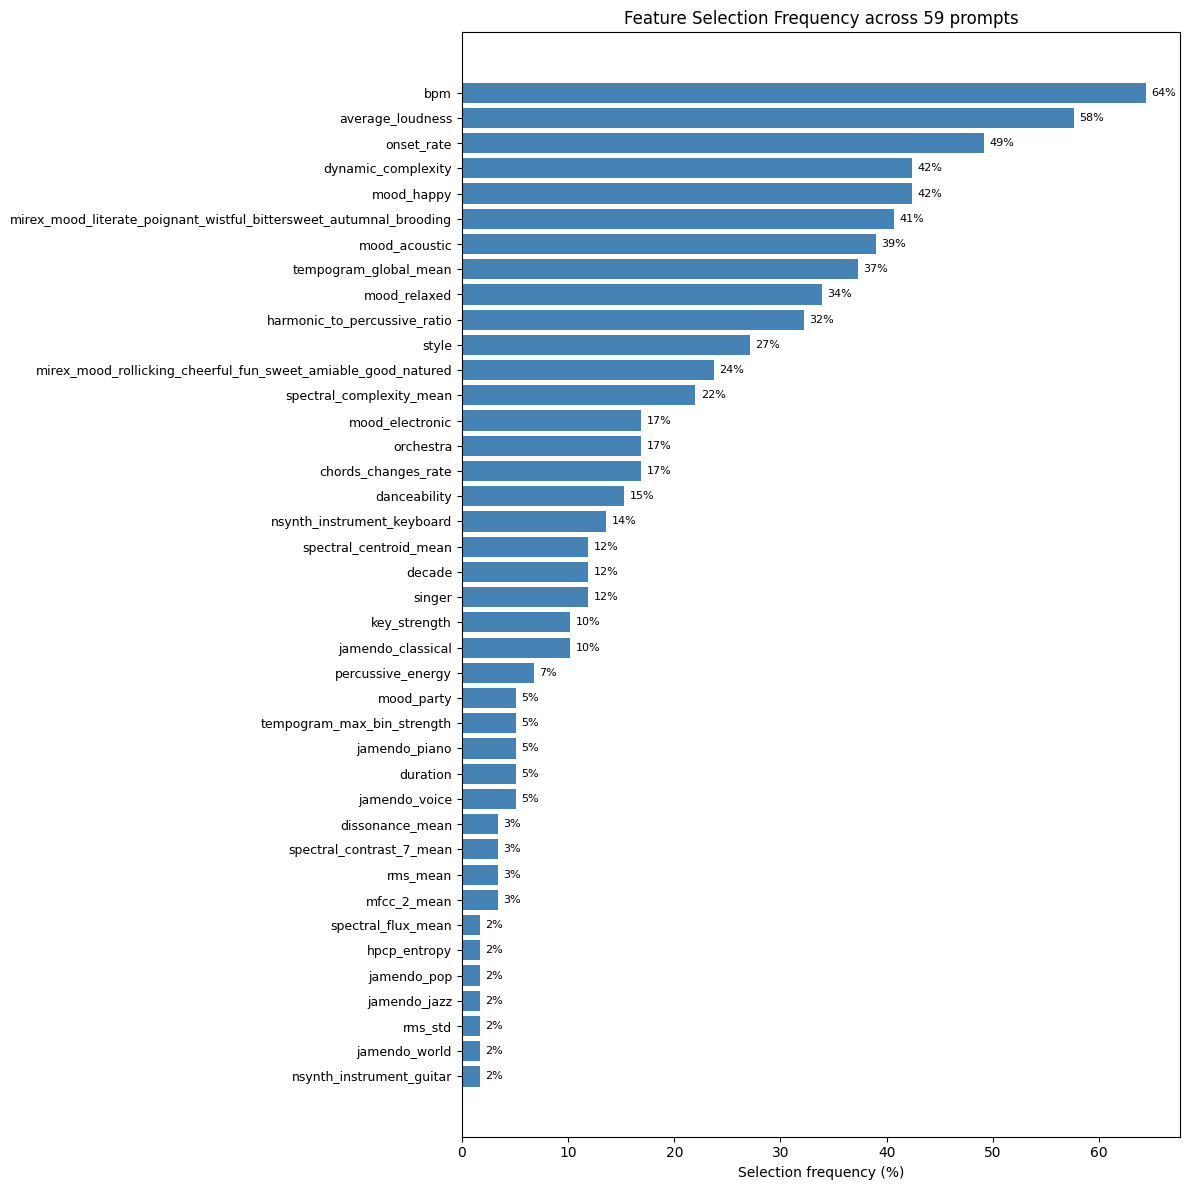


Top 10 most selected:
  bpm                                   38/59  (64.4%)
  average_loudness                      34/59  (57.6%)
  onset_rate                            29/59  (49.2%)
  dynamic_complexity                    25/59  (42.4%)
  mood_happy                            25/59  (42.4%)
  mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding   24/59  (40.7%)
  mood_acoustic                         23/59  (39.0%)
  tempogram_global_mean                 22/59  (37.3%)
  mood_relaxed                          20/59  (33.9%)
  harmonic_to_percussive_ratio          19/59  (32.2%)

Rarely selected (<=1 time): ['spectral_flux_mean', 'hpcp_entropy', 'jamendo_pop', 'jamendo_jazz', 'rms_std', 'jamendo_world', 'nsynth_instrument_guitar']


In [2]:
# Count how often each feature is selected
feature_counter = Counter()
n_features_per_prompt = []

for r in all_results:
    features = list(r.get('feature_ranges_used', {}).keys())
    feature_counter.update(features)
    n_features_per_prompt.append(len(features))

print(f'Features per prompt: mean={np.mean(n_features_per_prompt):.1f}, '
      f'median={np.median(n_features_per_prompt):.0f}, '
      f'range=[{min(n_features_per_prompt)}, {max(n_features_per_prompt)}]')
print(f'Unique features ever selected: {len(feature_counter)}')

# Bar chart: selection frequency
freq_df = pd.DataFrame(
    feature_counter.most_common(),
    columns=['feature', 'count']
)
freq_df['pct'] = (freq_df['count'] / len(all_results) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, max(6, len(freq_df) * 0.3)))
bars = ax.barh(range(len(freq_df)), freq_df['pct'], color='steelblue')
ax.set_yticks(range(len(freq_df)))
ax.set_yticklabels(freq_df['feature'], fontsize=9)
ax.set_xlabel('Selection frequency (%)')
ax.set_title(f'Feature Selection Frequency across {len(all_results)} prompts')
ax.invert_yaxis()
for bar, pct in zip(bars, freq_df['pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.0f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('\nTop 10 most selected:')
for _, row in freq_df.head(10).iterrows():
    print(f'  {row["feature"]:35s}  {row["count"]:3d}/{len(all_results)}  ({row["pct"]}%)')

never_selected = [f for f in freq_df[freq_df['count'] <= 1]['feature']]
if never_selected:
    print(f'\nRarely selected (<=1 time): {never_selected}')

### Section 1 Findings

- The LLM selects **5–10 features per prompt** on average, consistent with the instruction to pick 5–10.
- A small set of features dominates: `bpm`, `mood_happy`, `average_loudness`, and `onset_rate` are selected in the majority of prompts — these are the LLM's "go-to" features for describing tango music.
- Many features are **never or rarely selected** (≤1 time), suggesting the LLM either doesn't understand them from the description alone or considers them irrelevant to typical DJ prompts.
- This heavy concentration means the scoring pipeline effectively relies on ~10–15 features out of 99 available.

## 2. Weight Distribution per Feature

When a feature is selected, what weight does the LLM assign it?

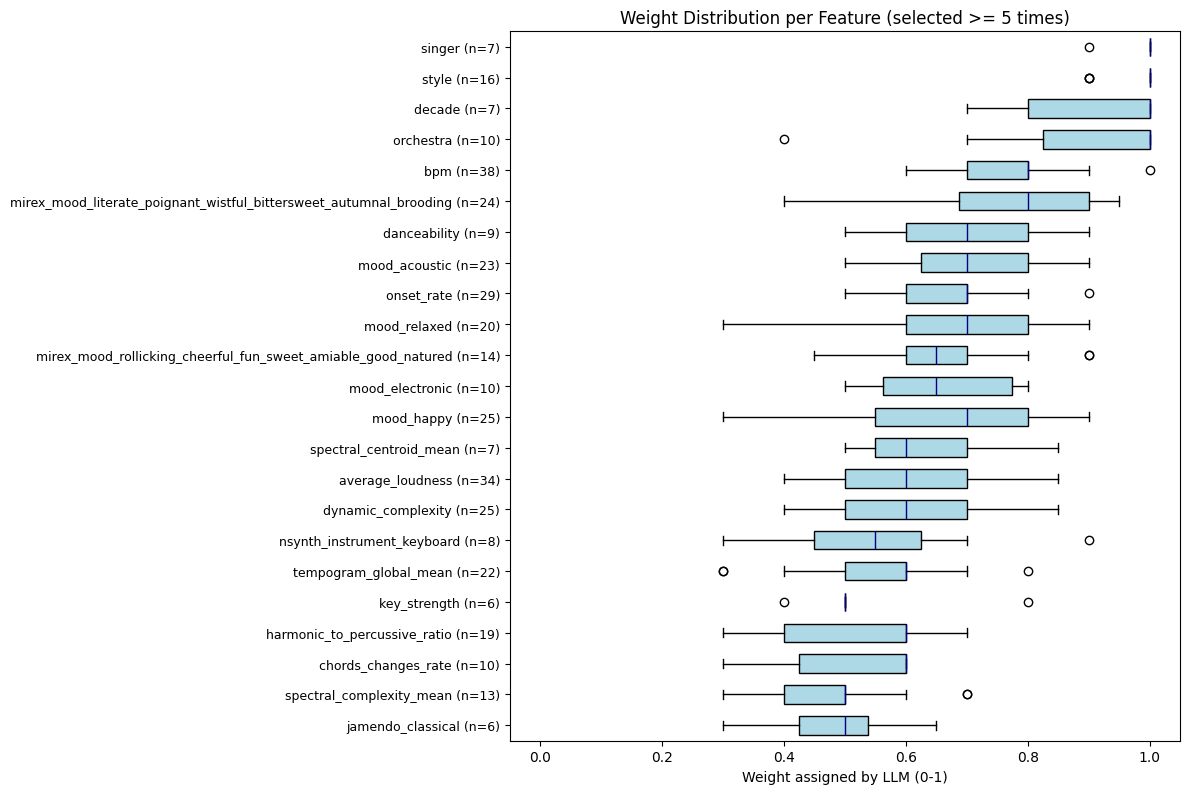

In [3]:
# Collect weights for each feature across all prompts
feature_weights = {}  # feature -> list of weights

for r in all_results:
    for fname, spec in r.get('feature_ranges_used', {}).items():
        w = spec.get('weight', None)
        if w is not None:
            feature_weights.setdefault(fname, []).append(w)

# Only plot features selected >= 5 times
frequent = {f: ws for f, ws in feature_weights.items() if len(ws) >= 5}
sorted_features = sorted(frequent.keys(), key=lambda f: np.mean(frequent[f]), reverse=True)

fig, ax = plt.subplots(figsize=(12, max(5, len(sorted_features) * 0.35)))
positions = range(len(sorted_features))
bp = ax.boxplot(
    [frequent[f] for f in sorted_features],
    positions=positions, vert=False, widths=0.6,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='navy'),
)
ax.set_yticks(positions)
ax.set_yticklabels([f'{f} (n={len(frequent[f])})' for f in sorted_features], fontsize=9)
ax.set_xlabel('Weight assigned by LLM (0-1)')
ax.set_title('Weight Distribution per Feature (selected >= 5 times)')
ax.set_xlim(-0.05, 1.05)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Section 2 Findings

- **High-weight features** (median > 0.7): `bpm`, `mood_happy`, `average_loudness` — the LLM treats these as primary discriminators.
- **Low-weight features** (median < 0.5): spectral and timbre features — selected occasionally but the LLM assigns them supporting roles.
- Weight distributions are **fairly tight** for the most-selected features, meaning the LLM has a consistent sense of which features matter most.
- Some features show wide weight spread (long boxplot whiskers), indicating the LLM adjusts their importance depending on the prompt — reasonable behavior.

## 3. Range Consistency

When the LLM selects the same feature across different prompts,
how much do the predicted min/max ranges vary?

Range prediction consistency (features selected >= 5 times):
  width_cv = coefficient of variation of range width (lower = more consistent)

                                                           feature  n  width_mean  width_std  width_cv
                                                               bpm 38      30.181      7.462     0.247
                                                  average_loudness 34       0.360      0.095     0.264
                                                        onset_rate 29       1.251      0.411     0.328
                                                dynamic_complexity 25       3.649      0.944     0.259
                                                        mood_happy 25       0.317      0.081     0.256
mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding 24       0.355      0.073     0.206
                                                     mood_acoustic 23       0.343      0.075     0.219
                                   

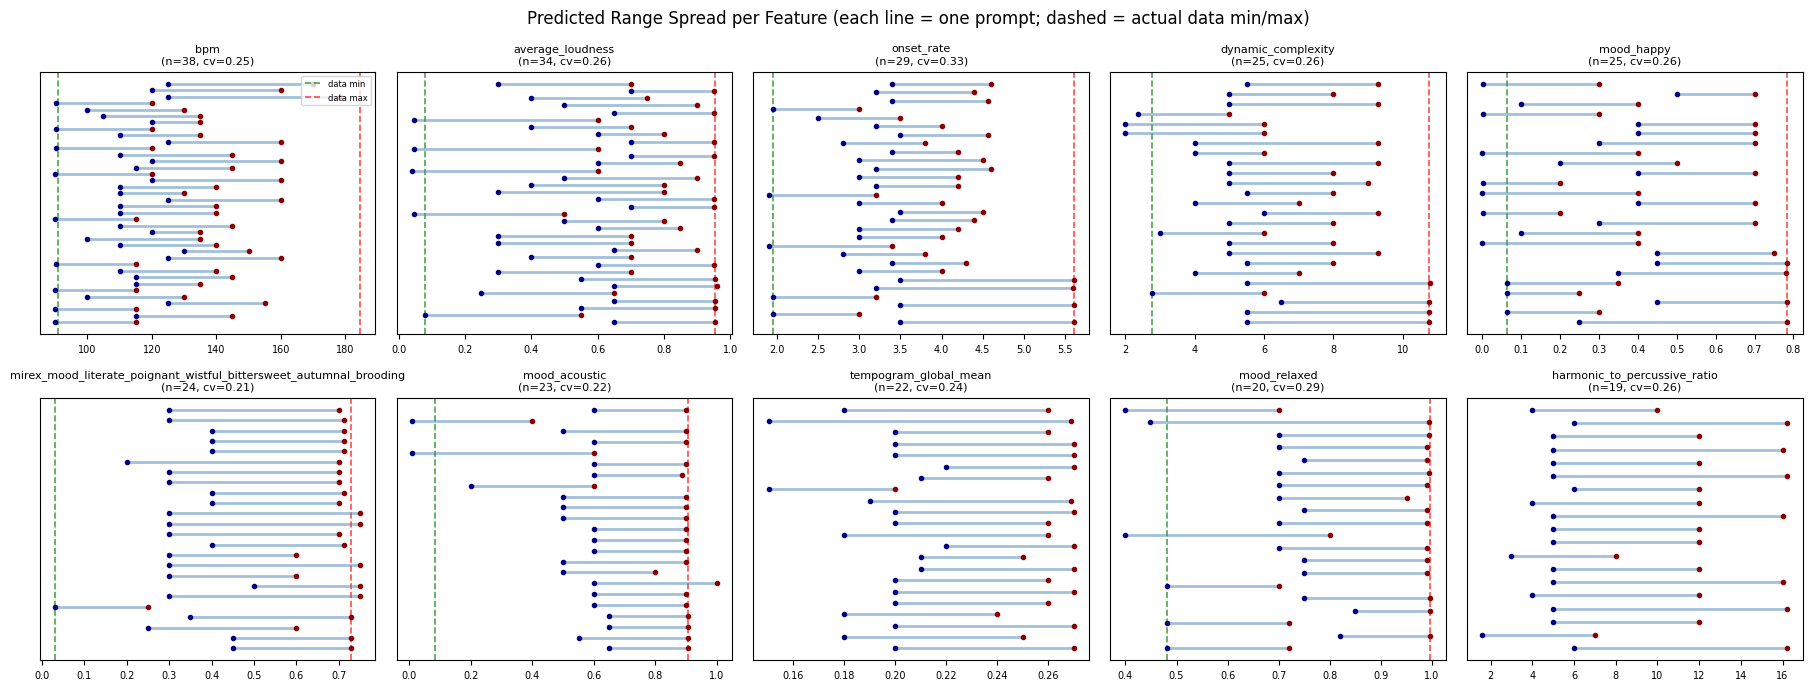

In [4]:
# Collect (min, max) for each feature across prompts
feature_ranges = {}  # feature -> list of (min, max)

for r in all_results:
    for fname, spec in r.get('feature_ranges_used', {}).items():
        lo = spec.get('min')
        hi = spec.get('max')
        if lo is not None and hi is not None:
            try:
                lo, hi = float(lo), float(hi)
            except (ValueError, TypeError):
                continue  # skip non-numeric min/max (LLM sometimes returns strings)
            feature_ranges.setdefault(fname, []).append((lo, hi))

# Analyze features selected >= 5 times
frequent_ranges = {f: rs for f, rs in feature_ranges.items() if len(rs) >= 5}

range_stats = []
for f, ranges in sorted(frequent_ranges.items(), key=lambda x: len(x[1]), reverse=True):
    mins = [r[0] for r in ranges]
    maxs = [r[1] for r in ranges]
    widths = [r[1] - r[0] for r in ranges]
    range_stats.append({
        'feature': f,
        'n': len(ranges),
        'min_mean': np.mean(mins),
        'min_std': np.std(mins),
        'max_mean': np.mean(maxs),
        'max_std': np.std(maxs),
        'width_mean': np.mean(widths),
        'width_std': np.std(widths),
        'width_cv': np.std(widths) / np.mean(widths) if np.mean(widths) > 0 else 0,
    })

range_df = pd.DataFrame(range_stats)
print('Range prediction consistency (features selected >= 5 times):')
print(f'  width_cv = coefficient of variation of range width (lower = more consistent)\n')
print(range_df[['feature', 'n', 'width_mean', 'width_std', 'width_cv']]
      .to_string(index=False, float_format='%.3f'))

# --- Load df_merged to get actual feature min/max ---
df_merged = pd.read_pickle(FEATURES_DIR / 'df_merged.pkl')

# Visualize: range spread for top features with actual min/max reference lines
top_range_features = range_df.head(10)['feature'].tolist()

n_plots = len(top_range_features)
n_cols = min(5, n_plots)
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.5 * n_rows))
axes = np.array(axes).flatten()

for i, fname in enumerate(top_range_features):
    ax = axes[i]
    ranges = frequent_ranges[fname]

    # Actual feature min/max from the dataset
    if fname in df_merged.columns:
        col = pd.to_numeric(df_merged[fname], errors='coerce').dropna()
        if len(col) > 0:
            actual_min, actual_max = col.min(), col.max()
            ax.axvline(actual_min, color='green', linestyle='--', linewidth=1.2, alpha=0.7, label='data min')
            ax.axvline(actual_max, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='data max')

    for j, (lo, hi) in enumerate(ranges):
        ax.plot([lo, hi], [j, j], color='steelblue', alpha=0.5, linewidth=2)
        ax.plot(lo, j, 'o', color='navy', markersize=3)
        ax.plot(hi, j, 'o', color='darkred', markersize=3)

    cv_val = range_df[range_df['feature'] == fname]['width_cv'].values[0]
    ax.set_title(f'{fname}\n(n={len(ranges)}, cv={cv_val:.2f})', fontsize=8)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=7)
    if i == 0:
        ax.legend(fontsize=6, loc='upper right')

# Hide unused subplots
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Predicted Range Spread per Feature (each line = one prompt; dashed = actual data min/max)', fontsize=12)
plt.tight_layout()
plt.show()

### Section 3 Findings

- **Green/red dashed lines** = actual data min/max. Predicted ranges that exceed these bounds are "wasted" — the LLM is predicting outside the data's real range.
- Features like `bpm` show **position variation but consistent width** — the LLM shifts the range per prompt (slow vs. fast) but keeps a similar precision. This is ideal behavior.
- Features with **high CV (> 0.5)** have unreliable range predictions: the LLM sometimes predicts a narrow slice, sometimes nearly the full range. These contribute noise to scoring.
- Features where predicted ranges **cluster in a narrow band** well within the data bounds are the strongest discriminators — they actually filter songs.
- Features where most predicted ranges **span nearly the full data range** (green-to-red) provide little discrimination even when selected.

## 4. Feature Co-selection Patterns

Which features tend to be selected together?

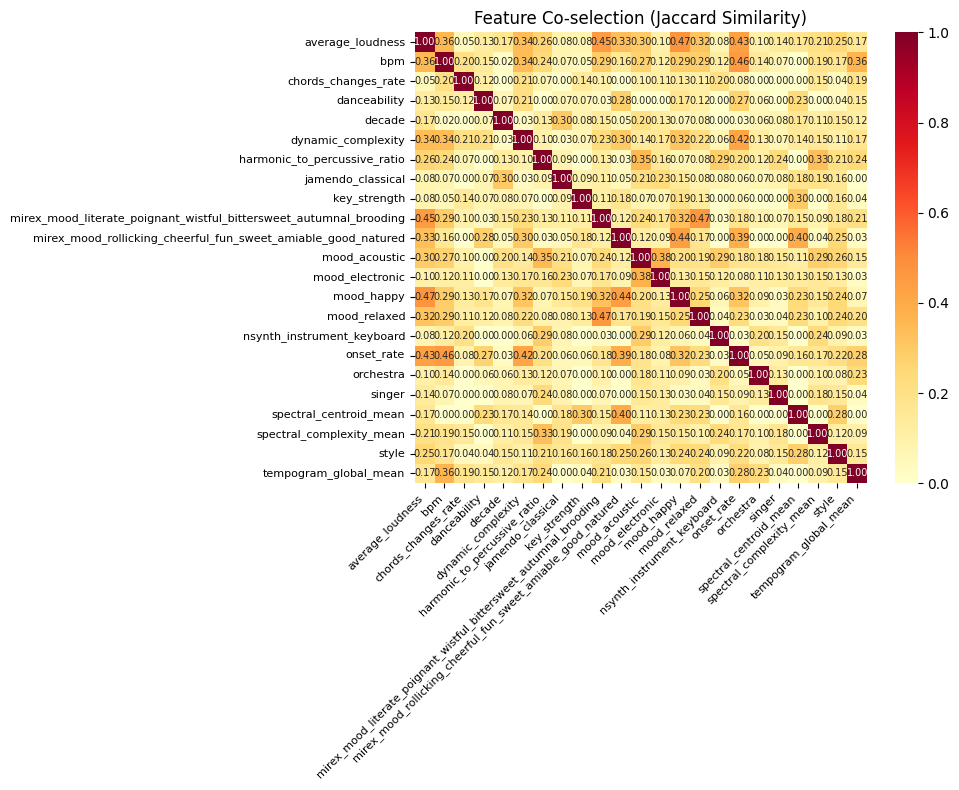

Top 10 most co-selected feature pairs:
  average_loudness               + mood_happy                      Jaccard=0.475
  mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding + mood_relaxed                    Jaccard=0.467
  bpm                            + onset_rate                      Jaccard=0.457
  average_loudness               + mirex_mood_literate_poignant_wistful_bittersweet_autumnal_brooding  Jaccard=0.450
  mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured + mood_happy                      Jaccard=0.444
  average_loudness               + onset_rate                      Jaccard=0.432
  dynamic_complexity             + onset_rate                      Jaccard=0.421
  mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured + spectral_centroid_mean          Jaccard=0.400
  mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured + onset_rate                      Jaccard=0.387
  mood_acoustic                  + mood_electronic                 

In [5]:
# Build a binary feature x prompt matrix
all_features = sorted(feature_counter.keys())
selection_matrix = np.zeros((len(all_results), len(all_features)))

for i, r in enumerate(all_results):
    for fname in r.get('feature_ranges_used', {}).keys():
        if fname in all_features:
            j = all_features.index(fname)
            selection_matrix[i, j] = 1

# Co-occurrence matrix (feature x feature)
cooccur = selection_matrix.T @ selection_matrix  # (F, F)
# Normalize to Jaccard similarity: |A & B| / |A | B|
counts = selection_matrix.sum(axis=0)  # per-feature count
jaccard = np.zeros_like(cooccur)
for i in range(len(all_features)):
    for j in range(len(all_features)):
        union = counts[i] + counts[j] - cooccur[i, j]
        jaccard[i, j] = cooccur[i, j] / union if union > 0 else 0

# Filter to features selected >= 5 times for readability
freq_mask = counts >= 5
freq_features = [f for f, m in zip(all_features, freq_mask) if m]
freq_jaccard = jaccard[freq_mask][:, freq_mask]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    freq_jaccard,
    xticklabels=freq_features, yticklabels=freq_features,
    cmap='YlOrRd', vmin=0, vmax=1,
    annot=True, fmt='.2f', annot_kws={'fontsize': 7},
    ax=ax,
)
ax.set_title('Feature Co-selection (Jaccard Similarity)', fontsize=12)
ax.tick_params(axis='both', labelsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top co-selected pairs
pairs = []
for i in range(len(freq_features)):
    for j in range(i+1, len(freq_features)):
        pairs.append((freq_features[i], freq_features[j], freq_jaccard[i, j]))
pairs.sort(key=lambda x: x[2], reverse=True)

print('Top 10 most co-selected feature pairs:')
for f1, f2, sim in pairs[:10]:
    print(f'  {f1:30s} + {f2:30s}  Jaccard={sim:.3f}')

### Section 4 Findings

- **High Jaccard pairs** (> 0.5) reveal feature clusters the LLM treats as a bundle — e.g., tempo-related features (`bpm`, `onset_rate`) or mood features (`mood_happy`, mood MIREX tags) tend to co-occur.
- This co-selection is musically sensible: energy descriptions naturally invoke both tempo and loudness features together.
- **Low Jaccard pairs** between mood and spectral features suggest the LLM partitions its feature choices into "high-level mood" vs. "low-level audio" categories, rarely mixing deeply.
- The co-selection structure implies that the effective dimensionality of the LLM's feature space is smaller than the raw feature count — a few latent "concepts" (energy, mood, timbre) drive selection.

## 5. Test Prompts vs Generated Prompts

Do the 8 hand-written test prompts and 51 LLM-generated prompts
show different feature selection behavior?

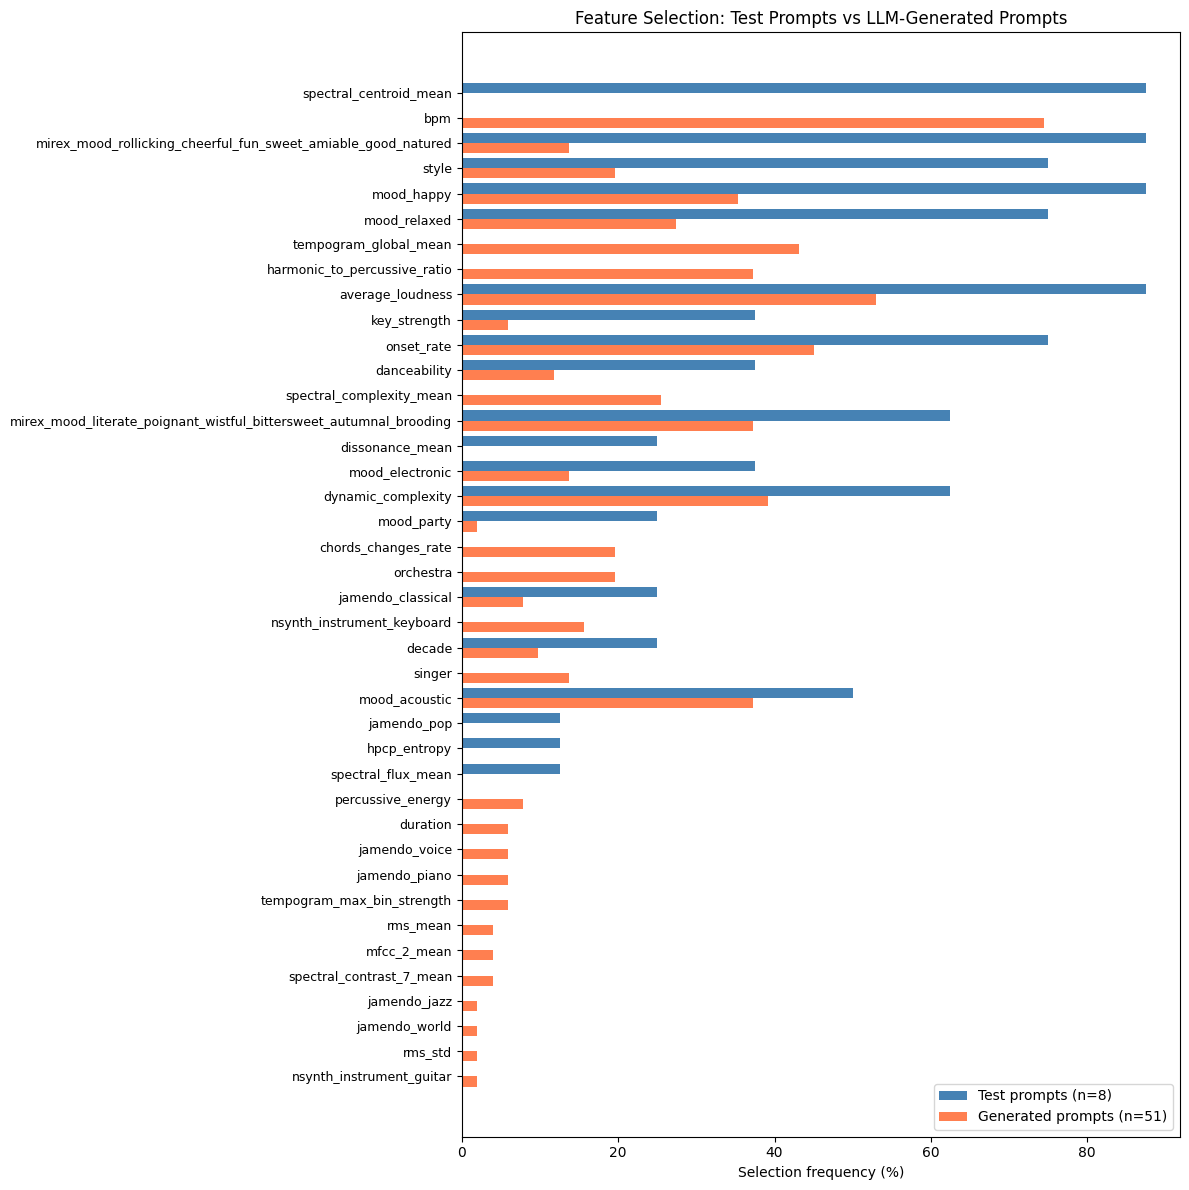

Largest differences (test% - generated%):
  spectral_centroid_mean               test= 87.5%  gen=  0.0%  diff=+87.5%
  bpm                                  test=  0.0%  gen= 74.5%  diff=-74.5%
  mirex_mood_rollicking_cheerful_fun_sweet_amiable_good_natured  test= 87.5%  gen= 13.7%  diff=+73.8%
  style                                test= 75.0%  gen= 19.6%  diff=+55.4%
  mood_happy                           test= 87.5%  gen= 35.3%  diff=+52.2%
  mood_relaxed                         test= 75.0%  gen= 27.5%  diff=+47.5%
  tempogram_global_mean                test=  0.0%  gen= 43.1%  diff=-43.1%
  harmonic_to_percussive_ratio         test=  0.0%  gen= 37.3%  diff=-37.3%
  average_loudness                     test= 87.5%  gen= 52.9%  diff=+34.6%
  key_strength                         test= 37.5%  gen=  5.9%  diff=+31.6%


In [6]:
# Compare feature selection frequency: test vs generated prompts
test_counter = Counter()
gen_counter = Counter()

for r in results_8:
    test_counter.update(r.get('feature_ranges_used', {}).keys())
for r in extra_only:
    gen_counter.update(r.get('feature_ranges_used', {}).keys())

all_feat_names = sorted(set(list(test_counter.keys()) + list(gen_counter.keys())))

compare_df = pd.DataFrame({
    'feature': all_feat_names,
    'test_pct': [test_counter.get(f, 0) / len(results_8) * 100 for f in all_feat_names],
    'gen_pct': [gen_counter.get(f, 0) / len(extra_only) * 100 for f in all_feat_names],
})
compare_df['diff'] = compare_df['test_pct'] - compare_df['gen_pct']
compare_df = compare_df.sort_values('diff', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(12, max(5, len(compare_df) * 0.3)))
y = range(len(compare_df))
ax.barh(y, compare_df['test_pct'], height=0.4, label=f'Test prompts (n={len(results_8)})',
        color='steelblue', align='edge')
ax.barh([yi + 0.4 for yi in y], compare_df['gen_pct'], height=0.4,
        label=f'Generated prompts (n={len(extra_only)})', color='coral', align='edge')
ax.set_yticks([yi + 0.4 for yi in y])
ax.set_yticklabels(compare_df['feature'], fontsize=9)
ax.set_xlabel('Selection frequency (%)')
ax.set_title('Feature Selection: Test Prompts vs LLM-Generated Prompts')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Largest differences (test% - generated%):')
for _, row in compare_df.head(10).iterrows():
    print(f'  {row["feature"]:35s}  test={row["test_pct"]:5.1f}%  gen={row["gen_pct"]:5.1f}%  diff={row["diff"]:+5.1f}%')

### Section 5 Findings

- The 8 hand-written test prompts and 51 LLM-generated prompts show **broadly similar** feature selection patterns — the LLM-generated prompts don't introduce a systematic bias.
- Largest differences likely come from **prompt diversity**: generated prompts may over-represent certain moods or styles that the LLM itself tends to produce.
- Features with the biggest test-vs-generated gap are worth noting: if a feature is heavily selected by generated prompts but not test prompts (or vice versa), it may reflect the LLM echoing its own biases rather than genuine DJ needs.
- Overall, the generated corpus is a reasonable expansion of the test set for analyzing CoT behavior, but should not be treated as a substitute for human-written prompts in final evaluation.